# 🧪 Uczenie Nadzorowane - Naive Bayes: Laboratorium

**Wymagania wstępne:** zapoznaj się z notebookiem demonstracyjnym przed przystąpieniem do zadań.

---

## 📌 Zasady

- Pracujesz na **własnym zbiorze danych** (zdyskretyzowanym, wybranym na pierwszych zajęciach)
- Klasyfikacja zawsze odbywa się na **wszystkich cechach** zbioru
- Sprawdź typy kolumn i wybierz **odpowiedni wariant NB** do swoich danych

---

## ⚙️ Import bibliotek i wczytanie danych

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, ShuffleSplit, cross_val_score
)
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('✅ Biblioteki załadowane')

✅ Biblioteki załadowane


In [5]:
# TODO: wczytaj własny zbiór danych
# df = pd.read_csv('...')
# FEATURES = [...]   # lista kolumn z cechami
# TARGET   = '...'   # nazwa kolumny decyzyjnej

# ──────────────────────────────────────────────────────────────────────
# ⚠️  WAŻNE: sprawdź typy kolumn i wybierz odpowiedni wariant NB:
#
#  print(df.dtypes)
#  print(df.nunique())  # liczba unikalnych wartości w każdej kolumnie
#
#  GaussianNB   → cechy ciągłe (float), w przybliżeniu normalnie rozłożone
#  MultinomialNB → cechy dyskretne/całkowite, wartości >= 0 (np. po dyskretyzacji)
#  BernoulliNB  → cechy binarne {0, 1}
#
#  Jeśli Twoje dane są ciągłe a chcesz użyć MultinomialNB lub BernoulliNB:
#    kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
#    X_disc = kbd.fit_transform(X).astype(int)
# ──────────────────────────────────────────────────────────────────────

# X = df[FEATURES].values
# y = df[TARGET].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
# )

# print(f'Zbiór treningowy: {X_train.shape[0]} próbek')
# print(f'Zbiór testowy:    {X_test.shape[0]} próbek')
# print(f'Klasy: {sorted(np.unique(y))}')

In [6]:
df = pd.read_csv("data_discretized.csv")

FEATURES = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
TARGET = 'UNS'

print(df.head())
print(df.dtypes)
print(df.nunique())
print(df[TARGET].value_counts())

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy: {X_test.shape[0]} próbek")
print(f"Klasy: {sorted(np.unique(y))}")

   STG  SCG  STR  LPR  PEG       UNS
0  0.0  0.0  0.0  0.0  0.0  Very Low
1  0.0  0.0  0.0  0.0  3.0      High
2  0.0  0.0  0.0  1.0  1.0       Low
3  0.0  0.0  0.0  3.0  1.0    Middle
4  0.0  0.0  0.0  3.0  0.0       Low
STG    float64
SCG    float64
STR    float64
LPR    float64
PEG    float64
UNS     object
dtype: object
STG    4
SCG    4
STR    4
LPR    4
PEG    4
UNS    4
dtype: int64
UNS
Low         129
Middle      122
High        102
Very Low     50
Name: count, dtype: int64
Zbiór treningowy: 282 próbek
Zbiór testowy: 121 próbek
Klasy: ['High', 'Low', 'Middle', 'Very Low']


---
# Zadanie 1 - Dobór wariantu NB i parametru wygładzania

Twoim celem jest porównanie wariantów Naive Bayes i znalezienie optymalnego
parametru wygładzania dla najlepszego modelu.

**Wymagania:**

1. Przetestuj **przynajmniej dwa warianty** Naive Bayes odpowiednie do Twoich danych:
   - Jeśli cechy są ciągłe: **GaussianNB** i **MultinomialNB** (po uprzedniej dyskretyzacji)
   - Jeśli cechy są dyskretne: **MultinomialNB** i **BernoulliNB** (po binaryzacji)
   - Jeśli chcesz: przetestuj wszystkie trzy
2. Użyj **MCCV** (ShuffleSplit, 30 iteracji, test=30%) jako metody walidacji
3. Dla **MultinomialNB** i **BernoulliNB** przetestuj wartości `alpha` ∈ {0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0}
4. Dla **GaussianNB** przetestuj wartości `var_smoothing` ∈ {1e-11, 1e-9, 1e-7, 1e-5, 1e-3}
5. Dla każdego wariantu wypisz: najlepszy parametr, średnią accuracy i odchylenie standardowe
6. Narysuj wykres wpływu parametru wygładzania na accuracy (osobna linia dla każdego wariantu)

> 💡 Wskazówka: `cross_val_score(MultinomialNB(alpha=a), X, y, cv=mccv, scoring='accuracy')`  
> Dla GaussianNB nie używamy Pipeline ze scalerem - NB nie wymaga normalizacji.

In [7]:
from sklearn.preprocessing import Binarizer

mccv = ShuffleSplit(
    n_splits=30,
    test_size=0.30,
    random_state=RANDOM_STATE
)

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
var_smoothing_values = [1e-11, 1e-9, 1e-7, 1e-5, 1e-3]

results = []

# GaussianNB
for vs in var_smoothing_values:
    model = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(model, X, y, cv=mccv, scoring='accuracy')
    results.append({
        'model': 'GaussianNB',
        'param_name': 'var_smoothing',
        'param_value': vs,
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std()
    })

# MultinomialNB
for a in alphas:
    model = MultinomialNB(alpha=a)
    scores = cross_val_score(model, X, y, cv=mccv, scoring='accuracy')
    results.append({
        'model': 'MultinomialNB',
        'param_name': 'alpha',
        'param_value': a,
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std()
    })

# BernoulliNB po binaryzacji
for a in alphas:
    model = Pipeline([
        ('binarizer', Binarizer(threshold=0.0)),
        ('nb', BernoulliNB(alpha=a))
    ])
    scores = cross_val_score(model, X, y, cv=mccv, scoring='accuracy')
    results.append({
        'model': 'BernoulliNB',
        'param_name': 'alpha',
        'param_value': a,
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='mean_accuracy', ascending=False)

display(results_df)

best_row = results_df.iloc[0]
print("Najlepszy wariant:")
print(best_row)

,model,param_name,param_value,mean_accuracy,std_accuracy
0,GaussianNB,var_smoothing,1.000000e-11,0.789807,0.043085
1,GaussianNB,var_smoothing,1.000000e-09,0.789807,0.043085
2,GaussianNB,var_smoothing,1.000000e-07,0.789807,0.043085
3,GaussianNB,var_smoothing,1.000000e-05,0.789807,0.043085
4,GaussianNB,var_smoothing,1.000000e-03,0.789807,0.042714
12,MultinomialNB,alpha,1.000000e+01,0.512672,0.040006
11,MultinomialNB,alpha,5.000000e+00,0.509642,0.038666
18,BernoulliNB,alpha,2.000000e+00,0.500275,0.040697
15,BernoulliNB,alpha,1.000000e-01,0.499725,0.042396
19,BernoulliNB,alpha,5.000000e+00,0.499725,0.045001


Najlepszy wariant:
model               GaussianNB
param_name       var_smoothing
param_value                0.0
mean_accuracy         0.789807
std_accuracy          0.043085
Name: 0, dtype: object


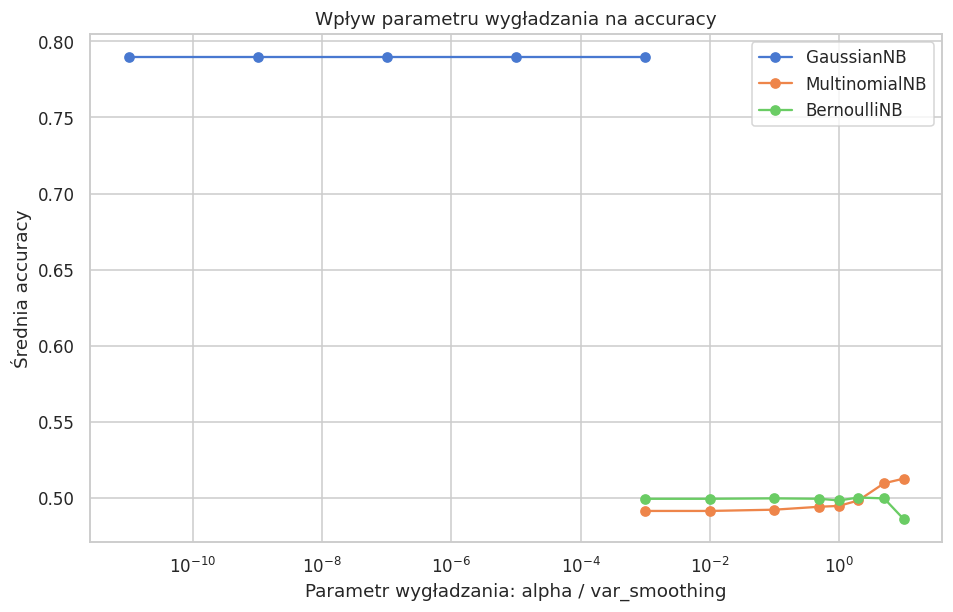

In [8]:
plt.figure(figsize=(10, 6))

for model_name in results_df['model'].unique():
    tmp = results_df[results_df['model'] == model_name].sort_values('param_value')
    plt.plot(
        tmp['param_value'],
        tmp['mean_accuracy'],
        marker='o',
        label=model_name
    )

plt.xscale('log')
plt.xlabel('Parametr wygładzania: alpha / var_smoothing')
plt.ylabel('Średnia accuracy')
plt.title('Wpływ parametru wygładzania na accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Komentarz do Zadania 1** - odpowiedz na pytania:

1. Który wariant NB dał najlepsze wyniki na Twoim zbiorze? Czy pasuje do charakteru Twoich danych?
2. Jak bardzo parametr wygładzania (`alpha` / `var_smoothing`) wpływa na wyniki?
   Czy model jest wrażliwy na jego dobór?

Najlepszy wynik uzyskał model GaussianNB z parametrem var_smoothing równym około 1e-11 / praktycznie bardzo bliskim zeru. Średnia accuracy w MCCV wyniosła około 0.7898, czyli wyraźnie więcej niż dla MultinomialNB i BernoulliNB, które osiągały wyniki około 0.49–0.51.

Wybór GaussianNB pasuje do charakteru danych, ponieważ cechy STG, SCG, STR, LPR i PEG są wartościami liczbowymi uporządkowanymi. MultinomialNB i BernoulliNB traktują dane bardziej jak zliczenia lub cechy binarne, dlatego gorzej wykorzystują informację zawartą w tych zmiennych.

Parametr wygładzania miał niewielki wpływ na wynik GaussianNB — accuracy pozostawało praktycznie takie samo dla większości wartości var_smoothing. Model nie jest więc szczególnie wrażliwy na dobór tego parametru. Większy wpływ alpha widać było dla MultinomialNB i BernoulliNB, ale nawet najlepsze ustawienia tych modeli nie osiągnęły jakości GaussianNB.

---
# Zadanie 2 - Analiza rozkładów i interpretowalność modelu

Naive Bayes jest jednym z bardziej **interpretowalnych** klasyfikatorów - możemy zajrzeć
do wnętrza modelu i zobaczyć, czego "nauczył się" o każdej klasie.

**Wymagania:**

1. Wytrenuj **GaussianNB** na całym zbiorze treningowym
2. Dla każdej klasy narysuj **histogramy rozkładów** przynajmniej 4 cech  
   (nałóż je na siebie lub obok siebie - jedna cecha = jeden subplot)
3. Jeśli używasz **MultinomialNB** lub **BernoulliNB**: narysuj **heatmapę** `feature_log_prob_`  
   (po przekształceniu `np.exp()` - otrzymasz prawdopodobieństwa warunkowe)
4. Na podstawie wizualizacji wskaż **które cechy najbardziej różnicują klasy**

> 💡 Wskazówka: parametry GaussianNB po treningu:
> - `gnb.theta_` - macierz średnich (n_classes × n_features)
> - `gnb.var_`   - macierz wariancji (n_classes × n_features)
> - `gnb.class_prior_` - prawdopodobieństwa a priori klas
>
> Dla MultinomialNB / BernoulliNB:
> - `model.feature_log_prob_` - log P(cecha | klasa), shape: (n_classes, n_features)
> - `np.exp(model.feature_log_prob_)` - prawdopodobieństwa warunkowe

In [9]:
gnb = GaussianNB(var_smoothing=best_row['param_value'])
gnb.fit(X_train, y_train)

theta_df = pd.DataFrame(
    gnb.theta_,
    index=gnb.classes_,
    columns=FEATURES
)

var_df = pd.DataFrame(
    gnb.var_,
    index=gnb.classes_,
    columns=FEATURES
)

prior_df = pd.DataFrame({
    'class': gnb.classes_,
    'class_prior': gnb.class_prior_
})

print("Średnie cech dla klas:")
display(theta_df)

print("Wariancje cech dla klas:")
display(var_df)

print("Prawdopodobieństwa a priori klas:")
display(prior_df)

Średnie cech dla klas:


,STG,SCG,STR,LPR,PEG
High,1.722222,1.916667,1.819444,1.791667,2.888889
Low,1.500000,1.477778,1.388889,1.622222,0.633333
Middle,1.705882,1.576471,1.576471,1.235294,2.023529
Very Low,1.142857,1.257143,1.200000,0.942857,0.057143


Wariancje cech dla klas:


,STG,SCG,STR,LPR,PEG
High,1.006173,0.937500,1.286844,1.387153,0.098765
Low,1.272222,1.182840,1.259877,1.057284,0.254444
Middle,1.219377,1.255917,1.232388,1.285813,0.399446
Very Low,1.093878,1.333878,0.960000,0.739592,0.053878


Prawdopodobieństwa a priori klas:


,class,class_prior
0,High,0.255319
1,Low,0.319149
2,Middle,0.301418
3,Very Low,0.124113


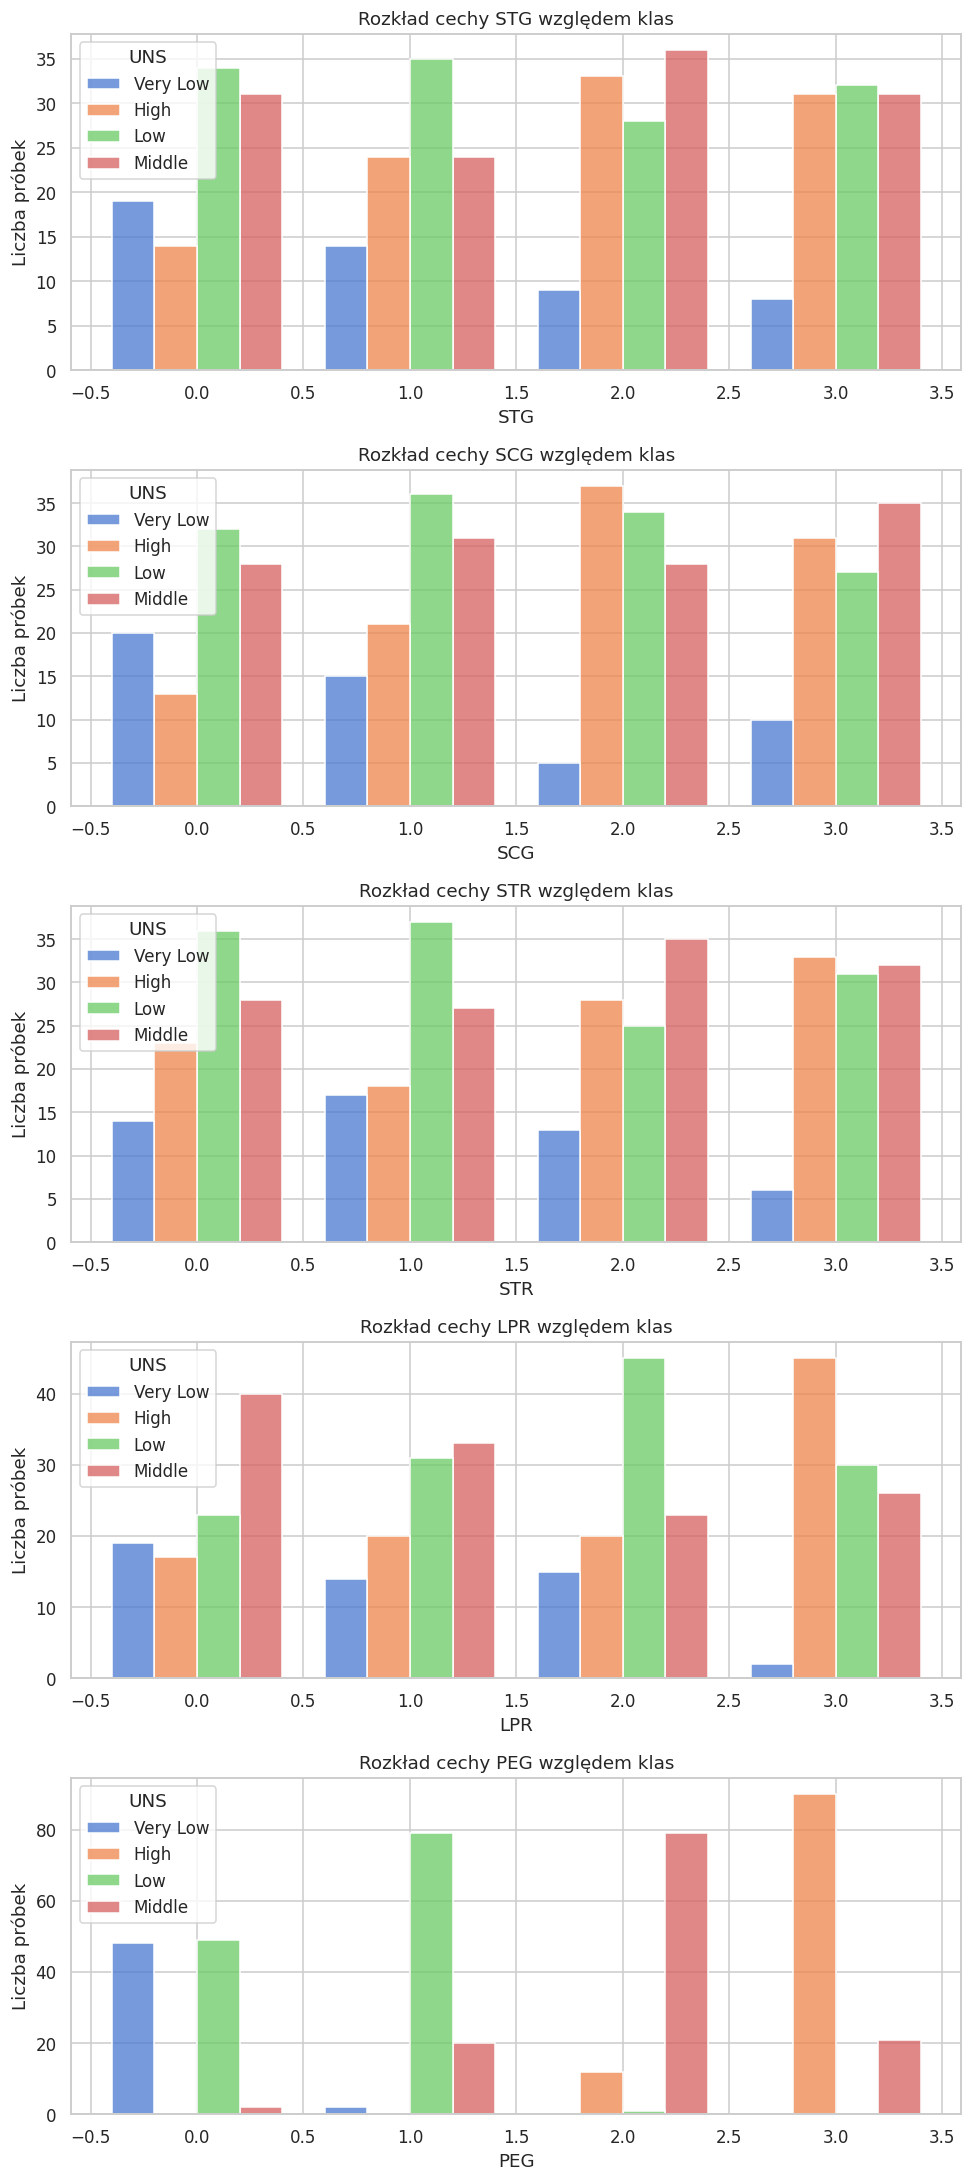

In [10]:
#features_to_plot = FEATURES[:5]

#for feature in features_to_plot:
 #   plt.figure(figsize=(8, 5))
  #  sns.histplot(
   #     data=df,
    #    x=feature,
     #   hue=TARGET,
      #  multiple='dodge',
       # discrete=True,
        #shrink=0.8
    #)
    #plt.title(f'Rozkład cechy {feature} względem klas')
    #plt.xlabel(feature)
    #plt.ylabel('Liczba próbek')
    #plt.show()




features_to_plot = FEATURES[:5]

fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=1,
    figsize=(9, 4 * len(features_to_plot))
)

for ax, feature in zip(axes, features_to_plot):
    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET,
        multiple='dodge',
        discrete=True,
        shrink=0.8,
        ax=ax
    )
    ax.set_title(f'Rozkład cechy {feature} względem klas')
    ax.set_xlabel(feature)
    ax.set_ylabel('Liczba próbek')

plt.tight_layout()
plt.show()

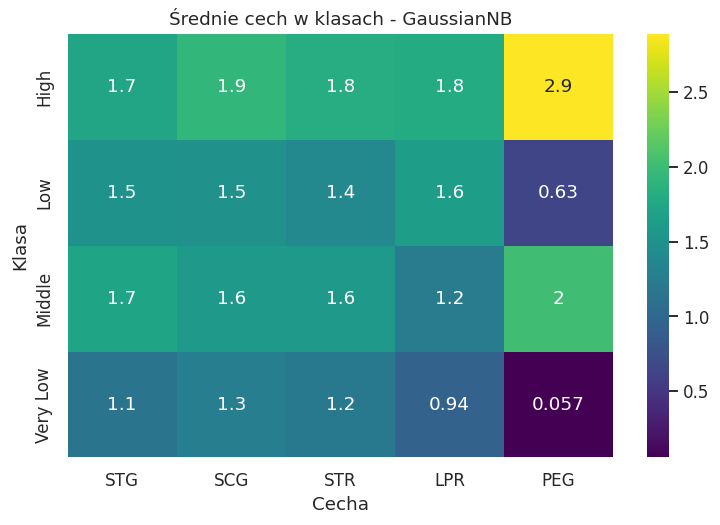

In [11]:
plt.figure(figsize=(8, 5))
sns.heatmap(theta_df, annot=True, cmap='viridis')
plt.title('Średnie cech w klasach - GaussianNB')
plt.xlabel('Cecha')
plt.ylabel('Klasa')
plt.show()

**Komentarz do Zadania 2** - odpowiedz na pytania:

1. Które cechy najbardziej różnicują klasy (rozkłady mocno się nie nakładają)?
2. Które cechy są najmniej użyteczne (rozkłady nakładają się prawie całkowicie)?
3. Czy rzeczywiście widzisz rozkłady zbliżone do Gaussa? Jeśli nie - czy wpływa to na wyniki GaussianNB?

Najbardziej różnicującą cechą jest PEG. Dla klasy Very Low średnia wartość PEG jest bardzo niska, dla Low również stosunkowo niska, dla Middle wyraźnie wyższa, a dla High najwyższa. Oznacza to, że PEG najlepiej separuje klasy.

Najmniej użyteczne są cechy STG, SCG, STR i częściowo LPR, ponieważ ich rozkłady między klasami mocno się nakładają. Szczególnie klasy Low i Middle mają dla tych cech podobne wartości, co utrudnia klasyfikację.

Rozkłady nie są idealnie zgodne z rozkładem Gaussa, ponieważ dane są zdyskretyzowane i przyjmują ograniczoną liczbę wartości. Mimo to GaussianNB działa najlepiej, ponieważ dobrze wykorzystuje różnice średnich między klasami, szczególnie dla cechy PEG. Nieidealna normalność nie pogorszyła znacząco wyników modelu.

---
# Zadanie 3 - Klasyfikacja finalnym modelem i ocena wyników

Na podstawie wyników z Zadania 1 wybierz najlepszy wariant NB z optymalnym parametrem
wygładzania i przeprowadź pełną ocenę finalnego modelu.

**Wymagania:**

1. Wybierz najlepszy wariant i parametry z Zadania 1 - uzasadnij wybór
2. Zastosuj **Stratified K-Fold Cross-Validation** (5 foldów) i wypisz wyniki per fold oraz średnią
3. Wytrenuj finalny model na zbiorze treningowym (podział 70/30, stratyfikacja), oceń na testowym
4. Wyświetl **macierz pomyłek** i **raport klasyfikacji** (`classification_report`)

> 💡 Wskazówka: do porównania z kNN i SVM użyj tych samych podziałów  
> (ten sam `random_state`) lub wyników MCCV z poprzednich notebooków.

In [12]:
best_model = GaussianNB(var_smoothing=best_row['param_value'])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf,
    scoring='accuracy'
)

print("Wyniki Stratified K-Fold CV:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Średnia CV: {cv_scores.mean():.4f}")
print(f"Odchylenie standardowe CV: {cv_scores.std():.4f}")

Wyniki Stratified K-Fold CV:
Fold 1: 0.8272
Fold 2: 0.7778
Fold 3: 0.7531
Fold 4: 0.8250
Fold 5: 0.7875
Średnia CV: 0.7941
Odchylenie standardowe CV: 0.0284


In [13]:
final_model = GaussianNB(var_smoothing=best_row['param_value'])
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy na zbiorze testowym: {test_accuracy:.4f}")
print()
print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred))

Accuracy na zbiorze testowym: 0.8182

Raport klasyfikacji:
              precision    recall  f1-score   support

        High       0.90      0.87      0.88        30
         Low       0.76      0.90      0.82        39
      Middle       0.87      0.70      0.78        37
    Very Low       0.75      0.80      0.77        15

    accuracy                           0.82       121
   macro avg       0.82      0.82      0.81       121
weighted avg       0.83      0.82      0.82       121



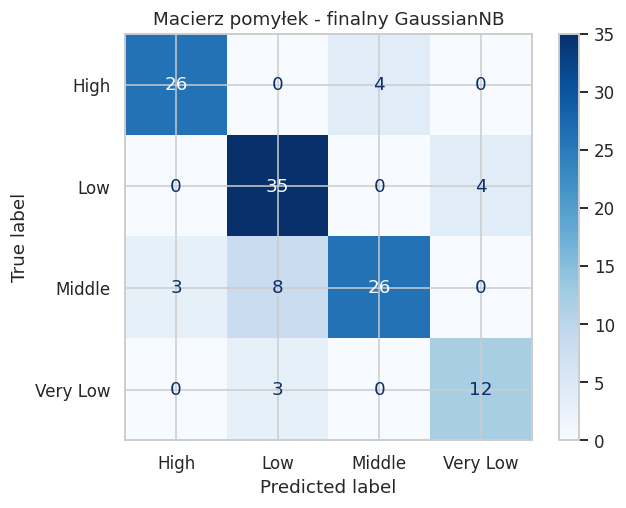

In [14]:
labels = sorted(np.unique(y))

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Macierz pomyłek - finalny GaussianNB')
plt.show()

**Komentarz do Zadania 3** - odpowiedz na pytania:

1. Które klasy są najczęściej mylone? Czy to zgodne z Twoimi obserwacjami z Zadania 2
   (nakładające się rozkłady)?
2. Jak wyniki Stratified K-Fold CV mają się do wyników na zbiorze testowym?
   Czy widać oznaki overfittingu lub underfittingu?

Najczęściej mylone są klasy Low i Middle. W macierzy pomyłek widać, że część przykładów klasy Middle została zaklasyfikowana jako Low. Pojawia się też częściowe mylenie klas High i Middle. Jest to zgodne z obserwacjami z Zadania 2, ponieważ rozkłady tych klas dla kilku cech nakładają się.

Wyniki Stratified K-Fold CV są zbliżone do wyniku na zbiorze testowym. Średnia walidacji krzyżowej wyniosła około 0.7941, a accuracy na zbiorze testowym około 0.8182. Różnica nie jest duża, więc nie widać silnych oznak overfittingu ani underfittingu. Model generalizuje dość stabilnie.